# CRF Baseline for Medical Dataset Name Extraction

This notebook trains and evaluates a **CRF (Conditional Random Field)** baseline model for extracting dataset names from medical research articles.

**Prerequisites:** Run `crf_data_preparation.ipynb` first to generate the BIO-tagged data in `crf_data/`.

| Step | Description |
|------|-------------|
| 1 | Setup and configuration |
| 2 | Load prepared BIO data |
| 3 | Feature engineering |
| 4 | Initial CRF training |
| 5 | Hyperparameter tuning with Optuna |
| 6 | Final evaluation on test set |
| 7 | Error analysis |
| 8 | Save model and push to HuggingFace |

## 1. Setup and Configuration

In [ ]:
# Install dependencies
# Uncomment the line below when running on Google Colab
%pip install -q sklearn-crfsuite spacy seqeval joblib huggingface_hub pandas matplotlib optuna
!python -m spacy download en_core_web_sm

In [1]:
import json
import os
import pickle
import warnings
from collections import Counter
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import optuna
import sklearn_crfsuite
from seqeval.metrics import (
    classification_report as seqeval_classification_report,
    f1_score as seqeval_f1,
)

warnings.filterwarnings('ignore', category=UserWarning)

# ============================================================
# CONFIGURATION
# ============================================================

DATA_DIR = "./crf_data"                                    # Input data from crf_data_preparation.ipynb
OUTPUT_DIR = "./crf_medical_ner"                           # Output directory for model artifacts
HF_REPO_ID = "haiderAI/crf-MedDataset-NER-540-samples-with-ODDTest"           # HuggingFace repo ID
HF_PRIVATE = True                                         # Whether to make the repo private
SEED = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Data directory:   {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"HuggingFace repo: {HF_REPO_ID}")

Data directory:   ./crf_data
Output directory: ./crf_medical_ner
HuggingFace repo: haiderAI/crf-MedDataset-NER-540-samples-with-ODDTest


## 2. Load Prepared Data

In [2]:
# Load sentence-level and chunk-level data for all splits
def load_pickle(filepath):
    with open(filepath, 'rb') as f:
        return pickle.load(f)

train_sentences = load_pickle(os.path.join(DATA_DIR, "train_sentences.pkl"))
val_sentences = load_pickle(os.path.join(DATA_DIR, "val_sentences.pkl"))
test_sentences = load_pickle(os.path.join(DATA_DIR, "test_sentences.pkl"))

train_chunks = load_pickle(os.path.join(DATA_DIR, "train_chunks.pkl"))
val_chunks = load_pickle(os.path.join(DATA_DIR, "val_chunks.pkl"))
test_chunks = load_pickle(os.path.join(DATA_DIR, "test_chunks.pkl"))

ood_sentences = load_pickle(os.path.join(DATA_DIR, "ood_sentences.pkl"))
ood_chunks = load_pickle(os.path.join(DATA_DIR, "ood_chunks.pkl"))

# Load metadata
with open(os.path.join(DATA_DIR, "metadata.json"), 'r') as f:
    metadata = json.load(f)

print(f"Data loaded from {DATA_DIR}/")
print(f"\n{'Split':<12} {'Chunks':>8} {'Sentences':>10}")
print("-" * 35)
print(f"{'Train':<12} {len(train_chunks):>8} {len(train_sentences):>10}")
print(f"{'Val':<12} {len(val_chunks):>8} {len(val_sentences):>10}")
print(f"{'Test':<12} {len(test_chunks):>8} {len(test_sentences):>10}")
print(f"{'OOD':<12} {len(ood_chunks):>8} {len(ood_sentences):>10}")
print("-" * 35)
total_c = len(train_chunks) + len(val_chunks) + len(test_chunks) + len(ood_chunks)
total_s = len(train_sentences) + len(val_sentences) + len(test_sentences) + len(ood_sentences)
print(f"{'Total':<12} {total_c:>8} {total_s:>10}")

Data loaded from ./crf_data/

Split          Chunks  Sentences
-----------------------------------
Train            5133      49027
Val               684       6474
Test             1028       9748
OOD              2825      27771
-----------------------------------
Total            9670      93020


In [3]:
# Display 5 sample sentences from train set
print("=" * 60)
print("SAMPLE TRAINING SENTENCES")
print("=" * 60)

sample_count = 0
for sent in train_sentences:
    if any(t != 'O' for t in sent['bio_tags']):
        print(f"\n--- Sample {sample_count + 1} ---")
        print(f"{'Token':<25} {'POS':<8} {'BIO Tag'}")
        print("-" * 50)
        for tok, pos, tag in zip(sent['tokens'], sent['pos_tags'], sent['bio_tags']):
            marker = " <<" if tag != 'O' else ""
            print(f"{tok:<25} {pos:<8} {tag}{marker}")
        sample_count += 1
        if sample_count >= 5:
            break

SAMPLE TRAINING SENTENCES

--- Sample 1 ---
Token                     POS      BIO Tag
--------------------------------------------------
LiTS                      PROPN    B-Dataset <<
(                         PUNCT    I-Dataset <<
LIver                     PROPN    I-Dataset <<
Tumor                     PROPN    I-Dataset <<
Segmentation              PROPN    I-Dataset <<
Benchmark                 PROPN    I-Dataset <<
)                         PUNCT    I-Dataset <<
includes                  VERB     O
201                       NUM      O
CT                        PROPN    O
scans                     NOUN     O
with                      ADP      O
0                         NUM      O
to                        PART     O
75                        NUM      O
liver                     NOUN     O
tumors                    NOUN     O
annotated                 VERB     O
per                       ADP      O
scan                      PROPN    O
.                         PUNCT    O

--- Sam

## 3. Feature Engineering

CRFs rely entirely on hand-crafted features since they have no learned representations (unlike transformers). We extract:

- **Word-level features**: lowercase form, suffixes, prefixes, character shape, boolean properties
- **POS tags**: Part-of-speech from spaCy
- **Context window**: Features from surrounding tokens (window of 2)
- **Bigram POS**: Adjacent POS tag combinations

In [4]:
def get_word_shape(word: str) -> str:
    """
    Convert word to shape pattern.
    X=upper, x=lower, d=digit, other characters kept as-is.
    Consecutive identical shape chars are collapsed.
    
    Examples:
        'CIFAR'   -> 'X'
        'CIFAR-10' -> 'X-d'
        'dataset'  -> 'x'
        'BraTS2020' -> 'XxXd'
    """
    shape = []
    for c in word:
        if c.isupper():
            shape.append('X')
        elif c.islower():
            shape.append('x')
        elif c.isdigit():
            shape.append('d')
        else:
            shape.append(c)
    
    # Collapse consecutive identical chars
    collapsed = []
    for c in shape:
        if not collapsed or collapsed[-1] != c:
            collapsed.append(c)
    return ''.join(collapsed)


def word2features(sent_tokens: List[str], sent_pos: List[str], i: int) -> Dict:
    """
    Extract features for token at position i in the sentence.
    """
    word = sent_tokens[i]
    pos = sent_pos[i]
    
    features = {
        # === Current word features ===
        'bias': 1.0,
        'word.lower()': word.lower(),
        'word[-3:]': word[-3:],              # suffix
        'word[-2:]': word[-2:],              # shorter suffix
        'word[:3]': word[:3],                # prefix
        'word[:2]': word[:2],                # shorter prefix
        'word.isupper()': word.isupper(),
        'word.istitle()': word.istitle(),
        'word.isdigit()': word.isdigit(),
        'word.isalpha()': word.isalpha(),
        'word.isalnum()': word.isalnum(),
        'postag': pos,
        
        # Word shape
        'word_shape': get_word_shape(word),
        
        # Contains specific characters
        'has_hyphen': '-' in word,
        'has_digit': any(c.isdigit() for c in word),
        'has_upper': any(c.isupper() for c in word),
        
        # Length
        'word_len': min(len(word), 20),
        
        # Position in sentence
        'sent_position': i / max(len(sent_tokens) - 1, 1),
        'is_first': i == 0,
        'is_last': i == len(sent_tokens) - 1,
    }
    
    # === Context features (window of 2) ===
    for offset in [-2, -1, 1, 2]:
        j = i + offset
        prefix = f'{offset:+d}:'
        if 0 <= j < len(sent_tokens):
            w = sent_tokens[j]
            p = sent_pos[j]
            features[f'{prefix}word.lower()'] = w.lower()
            features[f'{prefix}word.istitle()'] = w.istitle()
            features[f'{prefix}word.isupper()'] = w.isupper()
            features[f'{prefix}postag'] = p
            features[f'{prefix}has_hyphen'] = '-' in w
            features[f'{prefix}has_digit'] = any(c.isdigit() for c in w)
        else:
            features[f'{prefix}BOS'] = True  # boundary marker
    
    # === Bigram POS features ===
    if i > 0:
        features['bigram_pos_prev'] = f'{sent_pos[i-1]}|{pos}'
    if i < len(sent_tokens) - 1:
        features['bigram_pos_next'] = f'{pos}|{sent_pos[i+1]}'
    
    return features


def sent2features(sent: Dict) -> List[Dict]:
    """Convert a sentence dict to a list of feature dicts."""
    return [word2features(sent['tokens'], sent['pos_tags'], i)
            for i in range(len(sent['tokens']))]


def sent2labels(sent: Dict) -> List[str]:
    """Extract BIO labels from a sentence dict."""
    return sent['bio_tags']

In [5]:
# Convert all splits to feature/label format
print("Extracting features...")

X_train = [sent2features(s) for s in train_sentences]
y_train = [sent2labels(s) for s in train_sentences]

X_val = [sent2features(s) for s in val_sentences]
y_val = [sent2labels(s) for s in val_sentences]

X_test = [sent2features(s) for s in test_sentences]
y_test = [sent2labels(s) for s in test_sentences]

X_ood = [sent2features(s) for s in ood_sentences]
y_ood = [sent2labels(s) for s in ood_sentences]

print(f"Feature extraction complete.")
print(f"  Train: {len(X_train)} sequences")
print(f"  Val:   {len(X_val)} sequences")
print(f"  Test:  {len(X_test)} sequences")
print(f"  OOD:   {len(X_ood)} sequences")

# Count unique feature keys
all_keys = set()
for seq in X_train[:100]:  # sample for speed
    for feat_dict in seq:
        all_keys.update(feat_dict.keys())
print(f"  Unique feature keys (sample): {len(all_keys)}")

Extracting features...
Feature extraction complete.
  Train: 49027 sequences
  Val:   6474 sequences
  Test:  9748 sequences
  OOD:   27771 sequences
  Unique feature keys (sample): 50


In [6]:
# Display feature vector for a sample token
sample_sent = None
for s in train_sentences:
    if any(t != 'O' for t in s['bio_tags']):
        sample_sent = s
        break

if sample_sent:
    # Find a B-Dataset token
    for i, tag in enumerate(sample_sent['bio_tags']):
        if tag.startswith('B-'):
            print(f"Token: '{sample_sent['tokens'][i]}' (POS: {sample_sent['pos_tags'][i]}, Tag: {tag})")
            print(f"\nFeature vector:")
            features = word2features(sample_sent['tokens'], sample_sent['pos_tags'], i)
            for key, val in sorted(features.items()):
                print(f"  {key:<30} = {val}")
            break

Token: 'LiTS' (POS: PROPN, Tag: B-Dataset)

Feature vector:
  +1:has_digit                   = False
  +1:has_hyphen                  = False
  +1:postag                      = PUNCT
  +1:word.istitle()              = False
  +1:word.isupper()              = False
  +1:word.lower()                = (
  +2:has_digit                   = False
  +2:has_hyphen                  = False
  +2:postag                      = PROPN
  +2:word.istitle()              = False
  +2:word.isupper()              = False
  +2:word.lower()                = liver
  -1:BOS                         = True
  -2:BOS                         = True
  bias                           = 1.0
  bigram_pos_next                = PROPN|PUNCT
  has_digit                      = False
  has_hyphen                     = False
  has_upper                      = True
  is_first                       = True
  is_last                        = False
  postag                         = PROPN
  sent_position                  = 0.0
  w

## 4. Initial CRF Training

We use `sklearn-crfsuite` which implements a linear-chain CRF with L-BFGS optimization. Initial training uses reasonable default hyperparameters before tuning.

In [7]:
# Train initial CRF with default hyperparameters
crf = sklearn_crfsuite.CRF(
    algorithm='lbfgs',
    c1=0.1,                          # L1 regularization
    c2=0.1,                          # L2 regularization
    max_iterations=200,
    all_possible_transitions=True,   # Allow all label transitions
)

print("Training CRF with default hyperparameters (c1=0.1, c2=0.1)...")
crf.fit(X_train, y_train)
print("Training complete.")

Training CRF with default hyperparameters (c1=0.1, c2=0.1)...
Training complete.


In [8]:
# Quick sanity check on validation set
y_pred_val = crf.predict(X_val)

print("Validation set - seqeval classification report (default hyperparams):")
print(seqeval_classification_report(y_val, y_pred_val))

val_f1 = seqeval_f1(y_val, y_pred_val)
print(f"Entity-level F1: {val_f1:.4f}")

Validation set - seqeval classification report (default hyperparams):
              precision    recall  f1-score   support

     Dataset       0.91      0.91      0.91      1304

   micro avg       0.91      0.91      0.91      1304
   macro avg       0.91      0.91      0.91      1304
weighted avg       0.91      0.91      0.91      1304

Entity-level F1: 0.9091


## 5. Hyperparameter Tuning with Optuna

We use Optuna's Bayesian optimization to search for the best CRF regularization hyperparameters. The objective is entity-level F1 score (via seqeval) on the validation set.

**Search space:**
- `c1` (L1 regularization): log-uniform in [1e-3, 1.0]
- `c2` (L2 regularization): log-uniform in [1e-3, 1.0]
- `max_iterations`: {100, 200, 300}

In [9]:
optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial):
    c1 = trial.suggest_float('c1', 1e-3, 1.0, log=True)
    c2 = trial.suggest_float('c2', 1e-3, 1.0, log=True)
    max_iter = trial.suggest_categorical('max_iterations', [100, 200, 300])
    
    crf_trial = sklearn_crfsuite.CRF(
        algorithm='lbfgs',
        c1=c1,
        c2=c2,
        max_iterations=max_iter,
        all_possible_transitions=True,
    )
    crf_trial.fit(X_train, y_train)
    y_pred = crf_trial.predict(X_val)
    return seqeval_f1(y_val, y_pred)


print("Starting Optuna hyperparameter search (50 trials)...")
sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest trial:")
print(f"  F1 score: {study.best_value:.4f}")
print(f"  Parameters: {study.best_params}")

Starting Optuna hyperparameter search (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out



Best trial:
  F1 score: 0.9210
  Parameters: {'c1': 0.018010946644893652, 'c2': 0.028829101477515037, 'max_iterations': 100}


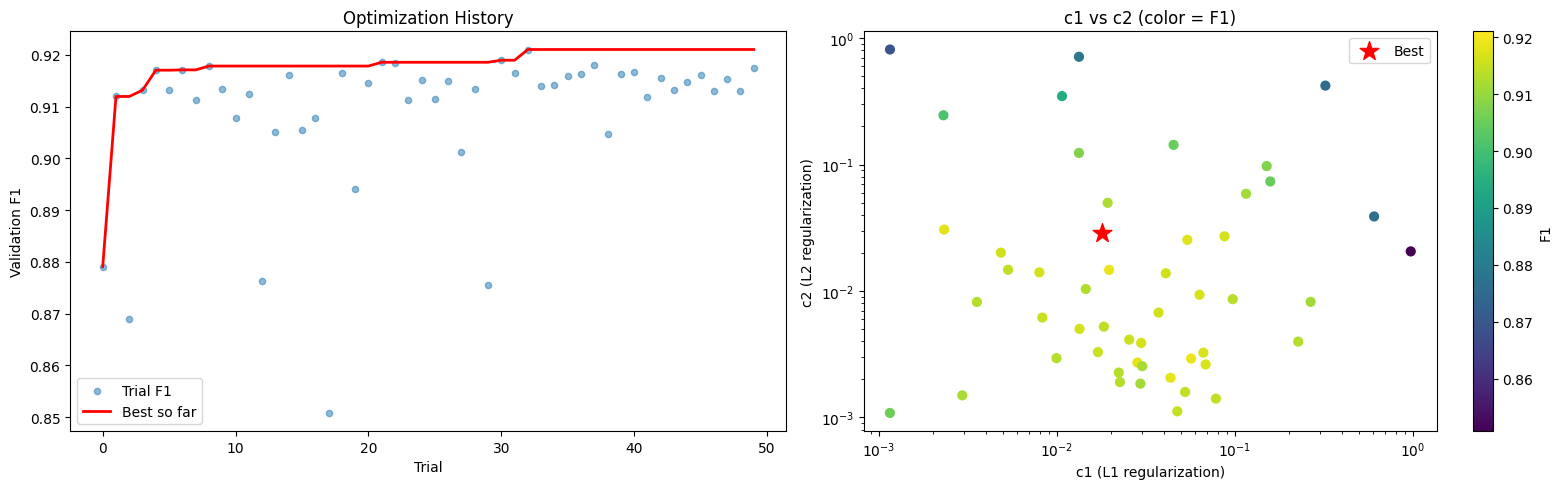

In [10]:
# Visualize Optuna results
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
  
# Optimization history
trials = study.trials
trial_numbers = [t.number for t in trials]
trial_values = [t.value for t in trials]
best_so_far = [max(trial_values[:i+1]) for i in range(len(trial_values))]

axes[0].scatter(trial_numbers, trial_values, alpha=0.5, s=20, label='Trial F1')
axes[0].plot(trial_numbers, best_so_far, color='red', linewidth=2, label='Best so far')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Validation F1')
axes[0].set_title('Optimization History')
axes[0].legend()

# c1 vs c2 scatter with F1 as color
c1_vals = [t.params['c1'] for t in trials]
c2_vals = [t.params['c2'] for t in trials]
sc = axes[1].scatter(c1_vals, c2_vals, c=trial_values, cmap='viridis', s=40)
axes[1].set_xlabel('c1 (L1 regularization)')
axes[1].set_ylabel('c2 (L2 regularization)')
axes[1].set_title('c1 vs c2 (color = F1)')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
plt.colorbar(sc, ax=axes[1], label='F1')

# Mark best trial
best = study.best_trial
axes[1].scatter([best.params['c1']], [best.params['c2']],
               marker='*', s=200, c='red', zorder=5, label='Best')
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
# Retrain final model with best hyperparameters
best_params = study.best_params
print(f"Retraining with best parameters: {best_params}")

best_crf = sklearn_crfsuite.CRF(
    algorithm='lbfgs',
    c1=best_params['c1'],
    c2=best_params['c2'],
    max_iterations=best_params['max_iterations'],
    all_possible_transitions=True,
)

best_crf.fit(X_train, y_train)

# Confirm validation F1
y_pred_val = best_crf.predict(X_val)
val_f1 = seqeval_f1(y_val, y_pred_val)
print(f"Validation entity-level F1: {val_f1:.4f}")
print(seqeval_classification_report(y_val, y_pred_val))

Retraining with best parameters: {'c1': 0.018010946644893652, 'c2': 0.028829101477515037, 'max_iterations': 100}


IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out


Validation entity-level F1: 0.9210
              precision    recall  f1-score   support

     Dataset       0.92      0.92      0.92      1304

   micro avg       0.92      0.92      0.92      1304
   macro avg       0.92      0.92      0.92      1304
weighted avg       0.92      0.92      0.92      1304



## 6. Final Evaluation on Test Set

We evaluate the best CRF model using two evaluation methodologies:

1. **seqeval** (token-level BIO evaluation) - standard NER evaluation
2. **Chunk-level exact & partial match** - matching the methodology from `training_full.ipynb` for direct comparison with GLiNER2

In [12]:
# seqeval classification report on test set
y_pred_test = best_crf.predict(X_test)

print("=" * 60)
print("TEST SET - seqeval Classification Report")
print("=" * 60)
print(seqeval_classification_report(y_test, y_pred_test))

test_f1_seqeval = seqeval_f1(y_test, y_pred_test)
print(f"Entity-level F1 (seqeval): {test_f1_seqeval:.4f}")

TEST SET - seqeval Classification Report
              precision    recall  f1-score   support

     Dataset       0.90      0.90      0.90      1904

   micro avg       0.90      0.90      0.90      1904
   macro avg       0.90      0.90      0.90      1904
weighted avg       0.90      0.90      0.90      1904

Entity-level F1 (seqeval): 0.9007


In [13]:
def bio_to_entity_strings(tokens: List[str], tags: List[str]) -> List[str]:
    """
    Decode BIO tags back to entity strings.
    Joins consecutive B-/I- tagged tokens with spaces.
    """
    entities = []
    current_tokens = []
    
    for tok, tag in zip(tokens, tags):
        if tag.startswith('B-'):
            if current_tokens:
                entities.append(' '.join(current_tokens))
            current_tokens = [tok]
        elif tag.startswith('I-') and current_tokens:
            current_tokens.append(tok)
        else:
            if current_tokens:
                entities.append(' '.join(current_tokens))
                current_tokens = []
    
    if current_tokens:
        entities.append(' '.join(current_tokens))
    
    return entities


def evaluate_chunk_level(chunks: List[Dict], sentences: List[Dict],
                         y_pred_flat: List[List[str]]) -> Dict:
    """
    Chunk-level exact & partial match evaluation.
    Matches the methodology from training_full.ipynb:460-520.
    
    Aggregates sentence-level predictions back to chunk level,
    decodes BIO tags to entity strings, and computes metrics.
    """
    # We need to map sentences back to chunks.
    # Each chunk has a known number of tokens; sentences were split from chunks.
    # Reconstruct by walking through predictions and matching token counts.
    
    sent_idx = 0
    tp = fp = fn = 0
    partial_tp = 0
    
    all_true_entities = []
    all_pred_entities = []
    
    for chunk in chunks:
        chunk_tokens = chunk['tokens']
        gold_entities = chunk['gold_entities']
        
        # Collect predicted tags for this chunk by aggregating sentences
        pred_tags = []
        remaining = len(chunk_tokens)
        
        while remaining > 0 and sent_idx < len(y_pred_flat):
            sent_pred = y_pred_flat[sent_idx]
            pred_tags.extend(sent_pred)
            remaining -= len(sent_pred)
            sent_idx += 1
        
        # Decode predicted entity strings
        pred_entity_strings = bio_to_entity_strings(chunk_tokens, pred_tags)
        
        # Normalize for comparison (matching training_full.ipynb approach)
        true_set = set(e.strip().lower() for e in gold_entities)
        pred_set = set(e.strip().lower() for e in pred_entity_strings)
        
        all_true_entities.append(true_set)
        all_pred_entities.append(pred_set)
        
        # Exact match
        tp += len(true_set & pred_set)
        fp += len(pred_set - true_set)
        fn += len(true_set - pred_set)
        
        # Partial match: check if non-exact pred is a substring of any true or vice versa
        for pmention in pred_set:
            if pmention not in true_set:
                for tmention in true_set:
                    if pmention in tmention or tmention in pmention:
                        partial_tp += 1
                        break
    
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-8)
    
    partial_precision = (tp + partial_tp) / max(tp + partial_tp + fp - partial_tp, 1)
    partial_recall = (tp + partial_tp) / max(tp + partial_tp + fn - partial_tp, 1)
    partial_f1 = 2 * partial_precision * partial_recall / max(partial_precision + partial_recall, 1e-8)
    
    return {
        "exact_match": {
            "precision": precision, "recall": recall, "f1": f1,
            "tp": tp, "fp": fp, "fn": fn,
        },
        "partial_match": {
            "precision": partial_precision, "recall": partial_recall, "f1": partial_f1,
            "partial_tp": partial_tp,
        },
        "all_true_entities": all_true_entities,
        "all_pred_entities": all_pred_entities,
    }

In [14]:
# Chunk-level evaluation on test set
test_metrics = evaluate_chunk_level(test_chunks, test_sentences, y_pred_test)

# Also evaluate on validation set for reference
val_metrics = evaluate_chunk_level(val_chunks, val_sentences, y_pred_val)

print("=" * 60)
print("CHUNK/SPAN/Entity-LEVEL EVALUATION")
print("=" * 60)

print(f"\n{'Metric':<20} {'Val':>10} {'Test (ID)':>10}")
print("-" * 45)
print(f"{'Exact P':<20} {val_metrics['exact_match']['precision']:>10.4f} {test_metrics['exact_match']['precision']:>10.4f}")
print(f"{'Exact R':<20} {val_metrics['exact_match']['recall']:>10.4f} {test_metrics['exact_match']['recall']:>10.4f}")
print(f"{'Exact F1':<20} {val_metrics['exact_match']['f1']:>10.4f} {test_metrics['exact_match']['f1']:>10.4f}")
print(f"{'Partial P':<20} {val_metrics['partial_match']['precision']:>10.4f} {test_metrics['partial_match']['precision']:>10.4f}")
print(f"{'Partial R':<20} {val_metrics['partial_match']['recall']:>10.4f} {test_metrics['partial_match']['recall']:>10.4f}")
print(f"{'Partial F1':<20} {val_metrics['partial_match']['f1']:>10.4f} {test_metrics['partial_match']['f1']:>10.4f}")
print(f"\nExact counts: TP={test_metrics['exact_match']['tp']}, FP={test_metrics['exact_match']['fp']}, FN={test_metrics['exact_match']['fn']}")
print(f"Partial TP (additional): {test_metrics['partial_match']['partial_tp']}")

CHUNK/SPAN/Entity-LEVEL EVALUATION

Metric                      Val  Test (ID)
---------------------------------------------
Exact P                  0.6812     0.6851
Exact R                  0.6851     0.6937
Exact F1                 0.6831     0.6894
Partial P                0.7198     0.7464
Partial R                0.7240     0.7558
Partial F1               0.7219     0.7511

Exact counts: TP=1051, FP=483, FN=464
Partial TP (additional): 94


### Out-of-Distribution (OOD) Evaluation

The OOD set tests generalization to entirely new documents not seen during training.
It uses **no negative sampling** and **no augmentation** -- natural entity distribution.

In [15]:
# seqeval classification report on OOD set
y_pred_ood = best_crf.predict(X_ood)

print("=" * 60)
print("OOD SET - seqeval Classification Report")
print("=" * 60)
print(seqeval_classification_report(y_ood, y_pred_ood))

ood_f1_seqeval = seqeval_f1(y_ood, y_pred_ood)
print(f"Entity-level F1 (seqeval): {ood_f1_seqeval:.4f}")

OOD SET - seqeval Classification Report
              precision    recall  f1-score   support

     Dataset       0.70      0.39      0.50      5353

   micro avg       0.70      0.39      0.50      5353
   macro avg       0.70      0.39      0.50      5353
weighted avg       0.70      0.39      0.50      5353

Entity-level F1 (seqeval): 0.5036


In [16]:
# Chunk-level evaluation on OOD set
ood_metrics = evaluate_chunk_level(ood_chunks, ood_sentences, y_pred_ood)

# Side-by-side comparison: Val vs Test (ID) vs OOD
print("=" * 60)
print("COMPARISON: Val vs Test (ID) vs OOD")
print("=" * 60)

print(f"\n{'Metric':<20} {'Val':>10} {'Test (ID)':>10} {'OOD':>10}")
print("-" * 55)
print(f"{'Exact P':<20} {val_metrics['exact_match']['precision']:>10.4f} {test_metrics['exact_match']['precision']:>10.4f} {ood_metrics['exact_match']['precision']:>10.4f}")
print(f"{'Exact R':<20} {val_metrics['exact_match']['recall']:>10.4f} {test_metrics['exact_match']['recall']:>10.4f} {ood_metrics['exact_match']['recall']:>10.4f}")
print(f"{'Exact F1':<20} {val_metrics['exact_match']['f1']:>10.4f} {test_metrics['exact_match']['f1']:>10.4f} {ood_metrics['exact_match']['f1']:>10.4f}")
print(f"{'Partial P':<20} {val_metrics['partial_match']['precision']:>10.4f} {test_metrics['partial_match']['precision']:>10.4f} {ood_metrics['partial_match']['precision']:>10.4f}")
print(f"{'Partial R':<20} {val_metrics['partial_match']['recall']:>10.4f} {test_metrics['partial_match']['recall']:>10.4f} {ood_metrics['partial_match']['recall']:>10.4f}")
print(f"{'Partial F1':<20} {val_metrics['partial_match']['f1']:>10.4f} {test_metrics['partial_match']['f1']:>10.4f} {ood_metrics['partial_match']['f1']:>10.4f}")

print(f"\nOOD exact counts: TP={ood_metrics['exact_match']['tp']}, FP={ood_metrics['exact_match']['fp']}, FN={ood_metrics['exact_match']['fn']}")
print(f"OOD partial TP (additional): {ood_metrics['partial_match']['partial_tp']}")

COMPARISON: Val vs Test (ID) vs OOD

Metric                      Val  Test (ID)        OOD
-------------------------------------------------------
Exact P                  0.6812     0.6851     0.5601
Exact R                  0.6851     0.6937     0.3349
Exact F1                 0.6831     0.6894     0.4192
Partial P                0.7198     0.7464     0.6583
Partial R                0.7240     0.7558     0.3936
Partial F1               0.7219     0.7511     0.4927

OOD exact counts: TP=1398, FP=1098, FN=2776
OOD partial TP (additional): 245


## 7. Error Analysis

In [17]:
# Collect concrete examples of TP, FP, FN, and partial matches
tp_examples = []
fp_examples = []
fn_examples = []
partial_examples = []

for true_set, pred_set in zip(test_metrics['all_true_entities'], test_metrics['all_pred_entities']):
    # True positives
    for e in true_set & pred_set:
        tp_examples.append(e)
    
    # False positives
    for e in pred_set - true_set:
        fp_examples.append(e)
    
    # False negatives
    for e in true_set - pred_set:
        fn_examples.append(e)
    
    # Partial matches
    for pmention in pred_set:
        if pmention not in true_set:
            for tmention in true_set:
                if pmention in tmention or tmention in pmention:
                    partial_examples.append((pmention, tmention))
                    break

print("=" * 60)
print("ERROR ANALYSIS - Concrete Examples")
print("=" * 60)

print(f"\n--- True Positives (showing 5 of {len(tp_examples)}) ---")
for e in tp_examples[:5]:
    print(f"  '{e}'")

print(f"\n--- False Positives (showing 5 of {len(fp_examples)}) ---")
for e in fp_examples[:5]:
    print(f"  '{e}'")

print(f"\n--- False Negatives (showing 5 of {len(fn_examples)}) ---")
for e in fn_examples[:5]:
    print(f"  '{e}'")

print(f"\n--- Partial Matches (showing 5 of {len(partial_examples)}) ---")
for pred, gold in partial_examples[:5]:
    print(f"  Predicted: '{pred}' | Gold: '{gold}'")

ERROR ANALYSIS - Concrete Examples

--- True Positives (showing 5 of 1051) ---
  'drive database'
  '3ma database'
  'adni2'
  'adni1'
  'biocreative 2.5'

--- False Positives (showing 5 of 483) ---
  'rdp - ii databases'
  'rdp - ii'
  'rdp - ii database'
  'ribosomal database project ( rdp - ii )'
  'medical segmentation decathlon ( msd ) challenge'

--- False Negatives (showing 5 of 464) ---
  'chembl'
  'brats 2018 survival validation dataset'
  'rdp-ii database'
  'rdp-ii'
  'rdp-ii databases'

--- Partial Matches (showing 5 of 94) ---
  Predicted: 'tcia' | Gold: 'the cancer imaging archive (tcia) corpus'
  Predicted: 'ham10000 ) dataset' | Gold: 'ham10000'
  Predicted: 'liver tumor segmentation benchmark ( lits )' | Gold: 'lits'
  Predicted: 'promise12 )' | Gold: 'promise12'
  Predicted: 'cehrner dataset' | Gold: 'cehrner'


In [18]:
# Error pattern analysis
print("=" * 60)
print("ERROR PATTERNS")
print("=" * 60)

# FP/FN by entity word count
fp_word_counts = Counter(len(e.split()) for e in fp_examples)
fn_word_counts = Counter(len(e.split()) for e in fn_examples)
tp_word_counts = Counter(len(e.split()) for e in tp_examples)

print("\nEntity length distribution (word count):")
all_lengths = sorted(set(list(fp_word_counts.keys()) + list(fn_word_counts.keys()) + list(tp_word_counts.keys())))
print(f"{'Length':<10} {'TP':>6} {'FP':>6} {'FN':>6}")
print("-" * 35)
for length in all_lengths[:10]:
    print(f"{length:<10} {tp_word_counts.get(length, 0):>6} {fp_word_counts.get(length, 0):>6} {fn_word_counts.get(length, 0):>6}")

# Most common FPs and FNs
print(f"\nMost common false positives:")
for entity, count in Counter(fp_examples).most_common(10):
    print(f"  '{entity}' (x{count})")

print(f"\nMost common false negatives (missed entities):")
for entity, count in Counter(fn_examples).most_common(10):
    print(f"  '{entity}' (x{count})")

ERROR PATTERNS

Entity length distribution (word count):
Length         TP     FP     FN
-----------------------------------
1             432     47    192
2             442     56    120
3             101    132     40
4              48     95     20
5              22     37     33
6               4     23     22
7               0     22     21
8               2     16     10
9               0     30      3
10              0      9      1

Most common false positives:
  'mimic - cxr' (x15)
  'ade20 k' (x8)
  'chestx - ray14 dataset' (x7)
  'coco - stuff' (x7)
  'mimic - iii dataset' (x7)
  'chestx - ray14' (x5)
  'men - rt' (x5)
  'ehr - relb' (x5)
  'brats' (x5)
  'ubfc - rppg' (x4)

Most common false negatives (missed entities):
  'mimic-cxr' (x14)
  'ade20k' (x9)
  'chestx-ray14 dataset' (x7)
  'coco-stuff' (x7)
  'brats' (x6)
  'mimic-iii dataset' (x6)
  'chestx-ray14' (x5)
  'mimic-iii' (x5)
  'ehr-relb' (x5)
  'ubfc-rppg' (x4)


In [19]:
# CRF model introspection - top feature weights
print("=" * 60)
print("CRF MODEL INTROSPECTION - Top Feature Weights")
print("=" * 60)

def print_top_features(crf, label, n=15):
    """Print top positive and negative feature weights for a label."""
    if not hasattr(crf, 'state_features_'):
        print(f"  Model does not expose state_features_")
        return
    
    # state_features_ is a dict: (attr, label) -> weight
    features = {}
    for (attr, lbl), weight in crf.state_features_.items():
        if lbl == label:
            features[attr] = weight
    
    if not features:
        print(f"  No features found for label '{label}'")
        return
    
    sorted_features = sorted(features.items(), key=lambda x: x[1], reverse=True)
    
    print(f"\n  Top {n} POSITIVE weights for '{label}':")
    for attr, weight in sorted_features[:n]:
        print(f"    {weight:>+8.4f}  {attr}")
    
    print(f"\n  Top {n} NEGATIVE weights for '{label}':")
    for attr, weight in sorted_features[-n:]:
        print(f"    {weight:>+8.4f}  {attr}")


for label in ['B-Dataset', 'I-Dataset']:
    print_top_features(best_crf, label)

CRF MODEL INTROSPECTION - Top Feature Weights

  Top 15 POSITIVE weights for 'B-Dataset':
     +7.3862  -1:word.lower():em
     +5.8687  word.lower():figshare
     +5.7514  word.lower():deeplesion
     +5.7446  word.lower():covidtracking
     +5.6130  word.lower():crossmed
     +5.6125  word.lower():inbreast
     +5.3176  word.lower():catech-256
     +5.2740  word.lower():medline
     +5.1470  -1:word.lower():qual-
     +5.0687  -2:word.lower():mgh
     +5.0400  word.lower():ham10000
     +5.0357  word.lower():chestct
     +5.0357  word[-3:]:tCT
     +4.6516  +1:word.lower():handpd
     +4.6516  +2:word.lower():+3.55

  Top 15 NEGATIVE weights for 'B-Dataset':
     -2.5888  +2:word.lower():go
     -2.6517  +2:word.lower():2019
     -3.0041  -2:word.lower():ct-82
     -3.0335  word[:3]:CXR
     -3.0700  word[-2:]:II
     -3.1323  +2:word.lower():competition
     -3.1432  postag:PUNCT
     -3.1441  -1:word.lower():-
     -3.1960  +2:word.lower():lpba40
     -3.2174  +1:word.lower():datab


Transition weights:


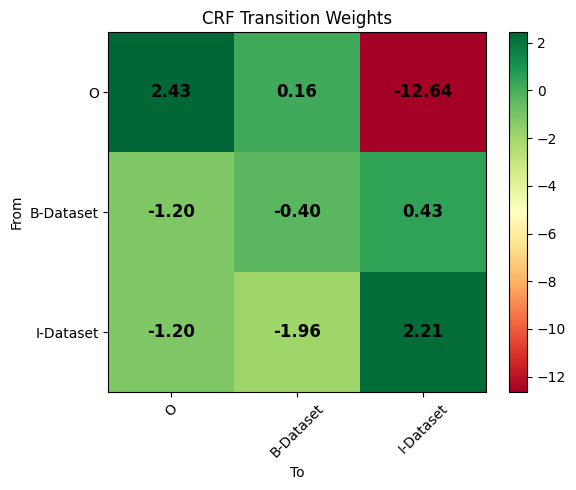


Expected patterns:
  B-Dataset -> I-Dataset: should be strongly positive
  I-Dataset -> I-Dataset: should be positive (multi-word entities)
  I-Dataset -> B-Dataset: should be negative (invalid transition)
  O -> I-Dataset: should be strongly negative (I without B)


In [20]:
# Transition weight matrix visualization
print("\nTransition weights:")

if hasattr(best_crf, 'transition_features_'):
    labels = ['O', 'B-Dataset', 'I-Dataset']
    trans_matrix = np.zeros((len(labels), len(labels)))
    
    for (from_label, to_label), weight in best_crf.transition_features_.items():
        if from_label in labels and to_label in labels:
            i = labels.index(from_label)
            j = labels.index(to_label)
            trans_matrix[i, j] = weight
    
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(trans_matrix, cmap='RdYlGn', aspect='auto')
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45)
    ax.set_yticklabels(labels)
    ax.set_xlabel('To')
    ax.set_ylabel('From')
    ax.set_title('CRF Transition Weights')
    
    # Add text annotations
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, f'{trans_matrix[i, j]:.2f}',
                   ha='center', va='center', fontsize=12, fontweight='bold')
    
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()
    
    print("\nExpected patterns:")
    print("  B-Dataset -> I-Dataset: should be strongly positive")
    print("  I-Dataset -> I-Dataset: should be positive (multi-word entities)")
    print("  I-Dataset -> B-Dataset: should be negative (invalid transition)")
    print("  O -> I-Dataset: should be strongly negative (I without B)")
else:
    print("Model does not expose transition_features_")

In [21]:
# OOD-specific error analysis
print("=" * 60)
print("OOD ERROR ANALYSIS")
print("=" * 60)

# Collect OOD-specific examples
ood_fp_examples = []
ood_fn_examples = []
ood_tp_examples = []

for true_set, pred_set in zip(ood_metrics['all_true_entities'], ood_metrics['all_pred_entities']):
    for e in true_set & pred_set:
        ood_tp_examples.append(e)
    for e in pred_set - true_set:
        ood_fp_examples.append(e)
    for e in true_set - pred_set:
        ood_fn_examples.append(e)

print(f"\n--- OOD False Positives (showing 5 of {len(ood_fp_examples)}) ---")
for e in ood_fp_examples[:5]:
    print(f"  '{e}'")

print(f"\n--- OOD False Negatives (showing 5 of {len(ood_fn_examples)}) ---")
for e in ood_fn_examples[:5]:
    print(f"  '{e}'")

print(f"\n--- OOD True Positives (showing 5 of {len(ood_tp_examples)}) ---")
for e in ood_tp_examples[:5]:
    print(f"  '{e}'")

# Compare ID vs OOD error rates
print(f"\n--- Error Rate Comparison ---")
id_total = test_metrics['exact_match']['tp'] + test_metrics['exact_match']['fp'] + test_metrics['exact_match']['fn']
ood_total = ood_metrics['exact_match']['tp'] + ood_metrics['exact_match']['fp'] + ood_metrics['exact_match']['fn']
print(f"  ID  - TP: {test_metrics['exact_match']['tp']}, FP: {test_metrics['exact_match']['fp']}, FN: {test_metrics['exact_match']['fn']}")
print(f"  OOD - TP: {ood_metrics['exact_match']['tp']}, FP: {ood_metrics['exact_match']['fp']}, FN: {ood_metrics['exact_match']['fn']}")

# Most common OOD FPs and FNs
from collections import Counter
print(f"\nMost common OOD false positives:")
for entity, count in Counter(ood_fp_examples).most_common(10):
    print(f"  '{entity}' (x{count})")

print(f"\nMost common OOD false negatives (missed entities):")
for entity, count in Counter(ood_fn_examples).most_common(10):
    print(f"  '{entity}' (x{count})")

OOD ERROR ANALYSIS

--- OOD False Positives (showing 5 of 1098) ---
  'brats benchmark datasets'
  'tof - mra'
  'mimic - cxr - jpg'
  'covid - ct dataset'
  'the cancer imaging archive'

--- OOD False Negatives (showing 5 of 2776) ---
  'promis dataset'
  'raos dataset'
  'brats benchmark datasets (2017–2019)'
  'medqa-cancer'
  'medqaro'

--- OOD True Positives (showing 5 of 1398) ---
  'raos dataset'
  'brats2019'
  'brats benchmark dataset'
  'mnist'
  'cifar-10'

--- Error Rate Comparison ---
  ID  - TP: 1051, FP: 483, FN: 464
  OOD - TP: 1398, FP: 1098, FN: 2776

Most common OOD false positives:
  'rsna' (x17)
  'covid - ct dataset' (x16)
  'tof - mra' (x15)
  'tcga - lihc dataset' (x14)
  'kauh - ccmd dataset' (x14)
  'med - node dataset' (x13)
  'mts - ct dataset' (x13)
  'retinal - oct2017 dataset' (x13)
  'cbis - ddsm' (x12)
  'hmu - gc - he-30 k' (x12)

Most common OOD false negatives (missed entities):
  'shidc-b-ki-67' (x44)
  'bcnb' (x36)
  'bcdata' (x35)
  'padchest' (x3

## 8. Save Model & Push to HuggingFace

In [22]:
import joblib

# Save CRF model
model_path = os.path.join(OUTPUT_DIR, 'crf_model.joblib')
joblib.dump(best_crf, model_path)
print(f"Model saved: {model_path} ({os.path.getsize(model_path)/1024/1024:.1f} MB)")

# Save config
config = {
    'entity_types': ['Dataset'],
    'entity_description': 'Names of datasets, corpus, collections, databases, benchmarks, or data collections used in scientific research',
    'bio_labels': ['O', 'B-Dataset', 'I-Dataset'],
    'hyperparameters': best_params,
    'algorithm': 'lbfgs',
    'spacy_model': 'en_core_web_sm',
    'feature_window': 2,
    'training_data': {
        'source': metadata.get('source_file', 'data-annotations.json'),
        'total_documents': metadata.get('total_documents', 0),
        'train_chunks': metadata['splits']['train']['chunks'],
        'val_chunks': metadata['splits']['val']['chunks'],
        'test_chunks': metadata['splits']['test']['chunks'],
        'train_sentences': metadata['splits']['train']['sentences'],
        'val_sentences': metadata['splits']['val']['sentences'],
        'test_sentences': metadata['splits']['test']['sentences'],
        'chunk_size': metadata.get('chunk_size', 1500),
        'chunk_overlap': metadata.get('chunk_overlap', 300),
        'negative_sample_ratio': metadata.get('negative_sample_ratio', 0.15),
        'augmentation_enabled': metadata.get('augmentation_enabled', True),
    },
}
config_path = os.path.join(OUTPUT_DIR, 'config.json')
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f"Config saved: {config_path}")

# Save evaluation metrics
eval_metrics = {
    'validation': {
        'seqeval_f1': val_f1,
        'exact_match': {k: v for k, v in val_metrics['exact_match'].items()},
        'partial_match': {k: v for k, v in val_metrics['partial_match'].items()},
    },
    'test': {
        'seqeval_f1': test_f1_seqeval,
        'exact_match': {k: v for k, v in test_metrics['exact_match'].items()},
        'partial_match': {k: v for k, v in test_metrics['partial_match'].items()},
    },
    'ood': {
        'seqeval_f1': ood_f1_seqeval,
        'exact_match': {k: v for k, v in ood_metrics['exact_match'].items()},
        'partial_match': {k: v for k, v in ood_metrics['partial_match'].items()},
    },
}
metrics_path = os.path.join(OUTPUT_DIR, 'eval_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(eval_metrics, f, indent=2)
print(f"Metrics saved: {metrics_path}")

Model saved: ./crf_medical_ner/crf_model.joblib (1.9 MB)
Config saved: ./crf_medical_ner/config.json
Metrics saved: ./crf_medical_ner/eval_metrics.json


In [23]:
# Create inference.py helper script
inference_code = '''"""Standalone inference script for CRF Medical Dataset NER model."""
import joblib
import spacy
from typing import Dict, List


def get_word_shape(word: str) -> str:
    """Convert word to shape pattern (X=upper, x=lower, d=digit)."""
    shape = []
    for c in word:
        if c.isupper():
            shape.append('X')
        elif c.islower():
            shape.append('x')
        elif c.isdigit():
            shape.append('d')
        else:
            shape.append(c)
    collapsed = []
    for c in shape:
        if not collapsed or collapsed[-1] != c:
            collapsed.append(c)
    return ''.join(collapsed)


def word2features(sent_tokens: List[str], sent_pos: List[str], i: int) -> Dict:
    """Extract features for token at position i."""
    word = sent_tokens[i]
    pos = sent_pos[i]

    features = {
        'bias': 1.0,
        'word.lower()': word.lower(),
        'word[-3:]': word[-3:],
        'word[-2:]': word[-2:],
        'word[:3]': word[:3],
        'word[:2]': word[:2],
        'word.isupper()': word.isupper(),
        'word.istitle()': word.istitle(),
        'word.isdigit()': word.isdigit(),
        'word.isalpha()': word.isalpha(),
        'word.isalnum()': word.isalnum(),
        'postag': pos,
        'word_shape': get_word_shape(word),
        'has_hyphen': '-' in word,
        'has_digit': any(c.isdigit() for c in word),
        'has_upper': any(c.isupper() for c in word),
        'word_len': min(len(word), 20),
        'sent_position': i / max(len(sent_tokens) - 1, 1),
        'is_first': i == 0,
        'is_last': i == len(sent_tokens) - 1,
    }

    for offset in [-2, -1, 1, 2]:
        j = i + offset
        prefix = f'{offset:+d}:'
        if 0 <= j < len(sent_tokens):
            w = sent_tokens[j]
            p = sent_pos[j]
            features[f'{prefix}word.lower()'] = w.lower()
            features[f'{prefix}word.istitle()'] = w.istitle()
            features[f'{prefix}word.isupper()'] = w.isupper()
            features[f'{prefix}postag'] = p
            features[f'{prefix}has_hyphen'] = '-' in w
            features[f'{prefix}has_digit'] = any(c.isdigit() for c in w)
        else:
            features[f'{prefix}BOS'] = True

    if i > 0:
        features['bigram_pos_prev'] = f'{sent_pos[i-1]}|{pos}'
    if i < len(sent_tokens) - 1:
        features['bigram_pos_next'] = f'{pos}|{sent_pos[i+1]}'

    return features


def bio_to_entities(tokens: List[str], tags: List[str]) -> List[str]:
    """Decode BIO tags to entity strings."""
    entities = []
    current = []
    for tok, tag in zip(tokens, tags):
        if tag.startswith('B-'):
            if current:
                entities.append(' '.join(current))
            current = [tok]
        elif tag.startswith('I-') and current:
            current.append(tok)
        else:
            if current:
                entities.append(' '.join(current))
                current = []
    if current:
        entities.append(' '.join(current))
    return entities


def predict(text: str, crf, nlp) -> List[str]:
    """Extract dataset entities from text."""
    doc = nlp(text)
    all_entities = []

    for sent in doc.sents:
        tokens = [tok.text for tok in sent]
        pos_tags = [tok.pos_ for tok in sent]
        features = [word2features(tokens, pos_tags, i) for i in range(len(tokens))]
        tags = crf.predict([features])[0]
        all_entities.extend(bio_to_entities(tokens, tags))

    return list(set(all_entities))  # deduplicate


if __name__ == "__main__":
    import sys

    model_dir = sys.argv[1] if len(sys.argv) > 1 else "."
    crf = joblib.load(f"{model_dir}/crf_model.joblib")
    nlp = spacy.load("en_core_web_sm")

    sample_text = (
        "We evaluated our model on the MIMIC-III dataset and the ChestX-ray14 benchmark. "
        "Additional experiments were conducted on BraTS 2020 for brain tumor segmentation."
    )

    entities = predict(sample_text, crf, nlp)
    print(f"Extracted entities: {entities}")
'''

inference_path = os.path.join(OUTPUT_DIR, 'inference.py')
with open(inference_path, 'w', encoding='utf-8') as f:
    f.write(inference_code)
print(f"Inference script saved: {inference_path}")

Inference script saved: ./crf_medical_ner/inference.py


In [24]:
# HuggingFace login
from huggingface_hub import HfApi, login

login()  # Will prompt for token or use cached credentials
api = HfApi()

In [25]:
# Generate model card
em = test_metrics['exact_match']
pm = test_metrics['partial_match']
vem = val_metrics['exact_match']
vpm = val_metrics['partial_match']

oem = ood_metrics['exact_match']
opm = ood_metrics['partial_match']

model_card = f"""---
tags:
  - crf
  - ner
  - medical
  - sklearn-crfsuite
  - dataset-extraction
  - baseline
license: apache-2.0
---

# CRF Baseline - Medical Dataset Name Extraction

A CRF (Conditional Random Field) model trained to extract **dataset names** from medical/scientific research papers. This serves as a feature-engineered baseline to compare against neural NER models (GLiNER2).

## Entity Types

| Entity Type | Description |
|---|---|
| `Dataset` | Names of datasets, corpus, collections, databases, benchmarks, or data collections used in scientific research |

## Model Details

- **Architecture**: Linear-chain CRF (sklearn-crfsuite)
- **Algorithm**: L-BFGS
- **BIO scheme**: B-Dataset, I-Dataset, O
- **Tokenization**: spaCy `en_core_web_sm`
- **Features**: Word shape, POS tags, character n-grams, context window (2 tokens each direction)

## Training Details

| Parameter | Value |
|---|---|
| Data source | ~{metadata.get('total_documents', 'N/A')} annotated medical research papers (Label Studio) |
| Training chunks | {metadata['splits']['train']['chunks']} ({metadata['splits']['train']['sentences']} sentences) |
| Validation chunks | {metadata['splits']['val']['chunks']} ({metadata['splits']['val']['sentences']} sentences) |
| Test chunks | {metadata['splits']['test']['chunks']} ({metadata['splits']['test']['sentences']} sentences) |
| Chunk size | {metadata.get('chunk_size', 1500)} chars, {metadata.get('chunk_overlap', 300)} overlap |
| Negative sample ratio | {metadata.get('negative_sample_ratio', 0.15)} |
| Augmentation | {'Entity-centered (800 char windows)' if metadata.get('augmentation_enabled', True) else 'Disabled'} |
| c1 (L1 regularization) | {best_params['c1']:.6f} |
| c2 (L2 regularization) | {best_params['c2']:.6f} |
| max_iterations | {best_params['max_iterations']} |
| Tuning | Optuna Bayesian optimization (50 trials) |

## Evaluation Results

### Validation Set

| Metric | Exact Match | Partial Match |
|---|---|---|
| Precision | {vem['precision']:.4f} | {vpm['precision']:.4f} |
| Recall | {vem['recall']:.4f} | {vpm['recall']:.4f} |
| F1 | {vem['f1']:.4f} | {vpm['f1']:.4f} |

### Test Set (In-Distribution)

| Metric | Exact Match | Partial Match |
|---|---|---|
| Precision | {em['precision']:.4f} | {pm['precision']:.4f} |
| Recall | {em['recall']:.4f} | {pm['recall']:.4f} |
| F1 | {em['f1']:.4f} | {pm['f1']:.4f} |

### Out-of-Distribution (OOD) Test Set

| Metric | Exact Match | Partial Match |
|---|---|---|
| Precision | {oem['precision']:.4f} | {opm['precision']:.4f} |
| Recall | {oem['recall']:.4f} | {opm['recall']:.4f} |
| F1 | {oem['f1']:.4f} | {opm['f1']:.4f} |

seqeval entity-level F1: **{test_f1_seqeval:.4f}** (test), **{val_f1:.4f}** (val), **{ood_f1_seqeval:.4f}** (OOD)

## Usage

```python
import joblib
import spacy
from inference import predict

# Load model
crf = joblib.load("crf_model.joblib")
nlp = spacy.load("en_core_web_sm")

# Extract entities
text = "We evaluated our model on the MIMIC-III dataset and the ChestX-ray14 benchmark."
entities = predict(text, crf, nlp)
print(entities)  # ['MIMIC-III dataset', 'ChestX-ray14 benchmark']
```

## Dependencies

```
sklearn-crfsuite>=0.3.6
spacy>=3.0
joblib>=1.0
```

Plus spaCy model: `python -m spacy download en_core_web_sm`
"""

card_path = os.path.join(OUTPUT_DIR, 'README.md')
with open(card_path, 'w', encoding='utf-8') as f:
    f.write(model_card)
print(f"Model card saved: {card_path}")

Model card saved: ./crf_medical_ner/README.md


In [26]:
# Upload to HuggingFace Hub
print(f"Target repo: {HF_REPO_ID}")

api.create_repo(
    repo_id=HF_REPO_ID,
    private=HF_PRIVATE,
    exist_ok=True,
)

# Upload all artifacts
files_to_upload = [
    ('crf_model.joblib', 'crf_model.joblib'),
    ('config.json', 'config.json'),
    ('eval_metrics.json', 'eval_metrics.json'),
    ('inference.py', 'inference.py'),
    ('README.md', 'README.md'),
]

for local_name, repo_name in files_to_upload:
    local_path = os.path.join(OUTPUT_DIR, local_name)
    api.upload_file(
        path_or_fileobj=local_path,
        path_in_repo=repo_name,
        repo_id=HF_REPO_ID,
        commit_message=f"Upload {repo_name}",
    )
    print(f"  Uploaded: {repo_name}")

print(f"\nModel uploaded to: https://huggingface.co/{HF_REPO_ID}")

Target repo: haiderAI/crf-MedDataset-NER-540-samples-with-ODDTest


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

  Uploaded: crf_model.joblib
  Uploaded: config.json
  Uploaded: eval_metrics.json
  Uploaded: inference.py
  Uploaded: README.md

Model uploaded to: https://huggingface.co/haiderAI/crf-MedDataset-NER-540-samples-with-ODDTest


In [27]:
# Final summary
print("=" * 60)
print("CRF MODEL TRAINING COMPLETE")
print("=" * 60)

print(f"\nModel artifacts saved to: {OUTPUT_DIR}/")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    size = os.path.getsize(fpath)
    unit = 'KB' if size < 1024 * 1024 else 'MB'
    size_val = size / 1024 if unit == 'KB' else size / 1024 / 1024
    print(f"  {fname:<30} {size_val:>8.1f} {unit}")

print(f"\nHuggingFace repo: https://huggingface.co/{HF_REPO_ID}")

print(f"\nBest hyperparameters:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

print(f"\nKey metrics (test set):")
print(f"  seqeval F1:         {test_f1_seqeval:.4f}")
print(f"  Exact match F1:     {test_metrics['exact_match']['f1']:.4f}")
print(f"  Partial match F1:   {test_metrics['partial_match']['f1']:.4f}")

print(f"\nKey metrics (OOD set):")
print(f"  seqeval F1:         {ood_f1_seqeval:.4f}")
print(f"  Exact match F1:     {ood_metrics['exact_match']['f1']:.4f}")
print(f"  Partial match F1:   {ood_metrics['partial_match']['f1']:.4f}")

CRF MODEL TRAINING COMPLETE

Model artifacts saved to: ./crf_medical_ner/
  README.md                           2.5 KB
  config.json                         0.8 KB
  crf_model.joblib                    1.9 MB
  eval_metrics.json                   1.2 KB
  inference.py                        3.9 KB

HuggingFace repo: https://huggingface.co/haiderAI/crf-MedDataset-NER-540-samples-with-ODDTest

Best hyperparameters:
  c1: 0.018010946644893652
  c2: 0.028829101477515037
  max_iterations: 100

Key metrics (test set):
  seqeval F1:         0.9007
  Exact match F1:     0.6894
  Partial match F1:   0.7511

Key metrics (OOD set):
  seqeval F1:         0.5036
  Exact match F1:     0.4192
  Partial match F1:   0.4927
